# Amazon Product Sales Analysis

This project looks at Amazon product listings to understand which product and listing characteristics are associated with higher purchase activity.

The analysis focuses on product categories, pricing, discounts, ratings, reviews, Best Seller status, coupons, and sponsored listings.

## Business Questions

The analysis is built around a few practical questions:

1. Which product categories show the strongest purchase activity?
2. How are price, discount, rating, and review volume related to purchases?
3. Do Best Seller products show different purchase activity from other listings?
4. Are coupons and sponsored listings associated with higher purchase activity?
5. What characteristics are common among the highest-demand products?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

## Load and Understand the Dataset

I first loaded the cleaned Amazon product dataset and checked its size, columns, data types, and basic statistics before starting the analysis.

In [3]:
data = pd.read_csv("amazon_products_sales_data_cleaned.csv")

In [4]:
data.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [5]:
data.shape

(42675, 17)

### Dataset Overview

The dataset contains 42,675 product listing records and 17 columns before feature preparation. The analysis is performed at the listing/record level.

## Understand the Columns

The main fields used in the analysis are:

- **Product information:** `product_title`, `product_category`
- **Customer signals:** `product_rating`, `total_reviews`, `purchased_last_month`
- **Pricing:** `discounted_price`, `original_price`, `discount_percentage`
- **Promotional/listing signals:** `is_best_seller`, `is_sponsored`, `has_coupon`, `buy_box_availability`
- **Other listing information:** `delivery_date`, `sustainability_tags`, and URL fields

Not every field is used in the final analysis; columns with limited analytical value or very high missingness are removed later.

In [6]:
for column in data.columns:
    print(column)

product_title
product_rating
total_reviews
purchased_last_month
discounted_price
original_price
is_best_seller
is_sponsored
has_coupon
buy_box_availability
delivery_date
sustainability_tags
product_image_url
product_page_url
data_collected_at
product_category
discount_percentage


## Check Data Types

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

## Basic Statistical Summary

In [8]:
data.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


## Data Cleaning

Before looking at relationships, I checked missing values, duplicate rows, categorical fields, and a few basic value ranges.

I kept the cleaning steps fairly conservative because a missing value does not automatically mean the value was zero.

Before starting the analysis, I checked the dataset for missing values, duplicate
records, unnecessary columns, and inconsistent categorical values.

I also created a few simplified indicators that are easier to use during the analysis.

## Check Missing Values

Missing values are important here because several fields, especially purchase activity, are incomplete.

In [9]:
data.isnull().sum()

product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

In [10]:
(data.isnull().sum() / len(data) * 100).round(2)

product_title            0.00
product_rating           2.40
total_reviews            2.40
purchased_last_month    24.63
discounted_price         4.83
original_price           4.83
is_best_seller           0.00
is_sponsored             0.00
has_coupon               0.00
buy_box_availability    34.34
delivery_date           28.08
sustainability_tags     92.01
product_image_url        0.00
product_page_url         4.85
data_collected_at        0.00
product_category         0.00
discount_percentage      4.83
dtype: float64

The main missing fields are `purchased_last_month` (24.63%), `buy_box_availability` (34.34%), and `delivery_date` (28.08%). `sustainability_tags` is missing for about 92% of records.

For purchase-related analysis, I did **not** replace missing purchase values with zero. Missing purchase activity is treated as unavailable data and those rows are excluded from calculations that require purchase values.

## Remove columns that aren't useful

In [11]:
# Remove columns that are not needed for the analysis
data = data.drop(
    columns=[
        "sustainability_tags",
        "product_image_url",
        "product_page_url"
    ]
)

### Remove Unused Columns

The image URL and product page URL are not needed for the analysis. `sustainability_tags` also has very high missingness and is outside the main business questions.

I removed these fields to keep the working dataset focused on the variables used in the analysis.

In [12]:
data.shape

(42675, 14)

## Check duplicates

### Check for Duplicate Records

I checked for exact duplicate rows. No exact duplicate rows were found.

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
data["is_best_seller"].value_counts()

is_best_seller
No Badge             40814
Amazon's               744
Limited time deal      409
Best Seller            275
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64

### Review Categorical Variables

I reviewed the main categorical fields to understand their values and check whether the categories are suitable for comparison.

In [15]:
data["is_sponsored"].value_counts()

is_sponsored
Organic      35664
Sponsored     7011
Name: count, dtype: int64

In [16]:
data["has_coupon"].value_counts()

has_coupon
No Coupon                                    40727
Save $16.00  with coupon                       438
Save 15%  with coupon                          398
Save 10%  with coupon                          218
Save 5%  with coupon                           191
Save 50%  with coupon                          123
Save $11.00  with coupon                       120
Save $100.00  with coupon                       97
Save 40%  with coupon                           96
Save $25.00  with coupon                        65
Save $30.00  with coupon                        49
Save $69.00  with coupon                        31
Save 8%  with coupon                            18
Save $10.00  with coupon                        14
Save $33.00  with coupon                        13
Save $20.00  with coupon                         9
Save 20%  with coupon                            9
Save $18.00  with coupon                         8
Save $45.00  with coupon                         5
Save $15.00  with co

In [17]:
data["buy_box_availability"].value_counts(dropna=False)

buy_box_availability
Add to cart    28022
NaN            14653
Name: count, dtype: int64

In [18]:
data["product_category"].nunique()

15

In [19]:
data["product_category"].value_counts().head(20)

product_category
Other Electronics      8755
Laptops                8693
Phones                 6563
Cameras                3677
Power & Batteries      2877
TV & Display           2630
Chargers & Cables      1833
Storage                1630
Speakers               1345
Networking             1070
Headphones              997
Printers & Scanners     877
Gaming                  809
Smart Home              465
Wearables               454
Name: count, dtype: int64

In [20]:
# Simplify the coupon field into two groups
data["coupon_available"] = np.where(
    data["has_coupon"].str.startswith("Save", na=False),
    "Coupon Available",
    "No Coupon"
)

### Create Coupon Availability Indicator

For the analysis, the original coupon descriptions are simplified to `Coupon Available` and `No Coupon`.

In [21]:
data["coupon_available"].value_counts()

coupon_available
No Coupon           40727
Coupon Available     1948
Name: count, dtype: int64

## Feature Creation

A few simple indicators make the comparisons easier to read without changing the original fields.

In addition to the original dataset columns, I created a few simplified indicators
to make the analysis easier to interpret and compare across products.

In [22]:
data["best_seller"] = np.where(
    data["is_best_seller"] == "Best Seller",
    "Best Seller",
    "Not Best Seller"
)

### Create Best Seller Indicator

I treated a listing as a Best Seller only when `is_best_seller` is exactly `"Best Seller"`. Other badges such as deals or percentage-off messages are kept in the non-Best-Seller group.

In [23]:
data["best_seller"].value_counts()

best_seller
Not Best Seller    42400
Best Seller          275
Name: count, dtype: int64

## Check Purchase Activity

In [24]:
data["purchased_last_month"].describe()

count     32164.000000
mean       1293.665278
std        6318.323574
min          50.000000
25%         100.000000
50%         200.000000
75%         400.000000
max      100000.000000
Name: purchased_last_month, dtype: float64

In [25]:
data["purchased_last_month"].head(20)

0        300.0
1       6000.0
2       2000.0
3      10000.0
4      10000.0
5     100000.0
6      10000.0
7      10000.0
8          NaN
9      10000.0
10    100000.0
11     10000.0
12       100.0
13      1000.0
14       500.0
15    100000.0
16     80000.0
17    100000.0
18    100000.0
19     10000.0
Name: purchased_last_month, dtype: float64

In [26]:
data["purchased_last_month"].isnull().sum()

np.int64(10511)

In [27]:
data["purchased_last_month"].skew()

np.float64(10.72363655676025)

In [28]:
data["purchased_last_month"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25      100.0
0.50      200.0
0.75      400.0
0.90     1000.0
0.95     4000.0
0.99    20000.0
Name: purchased_last_month, dtype: float64

### Understand Purchase Activity

Purchase activity is strongly right-skewed. The median is 200 purchases, while the 90th percentile is about 1,000 and the top 1% is above 20,000.

Because a small number of listings have very high purchase counts, the median is more useful than the mean for describing a typical listing.

The purchase distribution is strongly right-skewed, so the analysis uses medians and log-transformed purchase values where appropriate.

### Create Buy Box indicator

In [29]:
data["buy_box_available"] = np.where(
    data["buy_box_availability"].notna(),
    "Available",
    "Not Available"
)

data["buy_box_available"].value_counts()

buy_box_available
Available        28022
Not Available    14653
Name: count, dtype: int64

### Create Buy Box Availability Indicator

For a simple comparison, I converted the presence of a `buy_box_availability` value into an availability indicator. Missing values are treated as `Not Available` for this descriptive flag; this does not mean the product was necessarily ineligible for the Buy Box.

## Check Numerical Data Types

I checked the data types and basic ranges before moving into exploratory analysis.

In [30]:
data.dtypes

product_title            object
product_rating          float64
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller           object
is_sponsored             object
has_coupon               object
buy_box_availability     object
delivery_date            object
data_collected_at        object
product_category         object
discount_percentage     float64
coupon_available         object
best_seller              object
buy_box_available        object
dtype: object

## Check Price Relationship

I checked whether any listing has a discounted price higher than its original price.

In [31]:
(data["original_price"] < data["discounted_price"]).sum()

np.int64(0)

## Check Discount Range

I checked for discount percentages below 0% or above 100%.

In [32]:
(data["discount_percentage"] < 0).sum()

np.int64(0)

In [33]:
(data["discount_percentage"] > 100).sum()

np.int64(0)

## Check Rating Range

I checked that product ratings stay within the expected 0–5 scale.

In [34]:
(data["product_rating"] < 0).sum()

np.int64(0)

In [35]:
(data["product_rating"] > 5).sum()

np.int64(0)

## Key Performance Indicators

In [36]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Products",
        "Average Rating",
        "Average Discount (%)",
        "Median Purchases Last Month",
        "Best Seller Products",
        "Best Seller Rate (%)"
    ],
    "Value": [
        data.shape[0],
        round(data["product_rating"].mean(), 2),
        round(data["discount_percentage"].mean(), 2),
        round(data["purchased_last_month"].median(), 0),
        data["best_seller"].eq("Best Seller").sum(),
        round(
            data["best_seller"].eq("Best Seller").mean() * 100,
            2
        )
    ]
})

kpi_summary

,Metric,Value
0,Total Products,42675.00
1,Average Rating,4.40
2,Average Discount (%),6.55
3,Median Purchases Last Month,200.00
4,Best Seller Products,275.00
5,Best Seller Rate (%),0.64


### Data Preparation Complete

The dataset is ready for exploratory analysis. I kept the original purchase values for business interpretation and use log-transformed values mainly for visualizations and correlation analysis where the extreme values would otherwise dominate.

## Exploratory Data Analysis

The next sections look at the distribution of products and then examine how product characteristics relate to purchase activity.

The exploratory analysis looks at the main characteristics of the products and
then compares them with purchase activity.

I started with individual variables before moving into relationships between
product attributes and demand.

# Product Rating Distribution

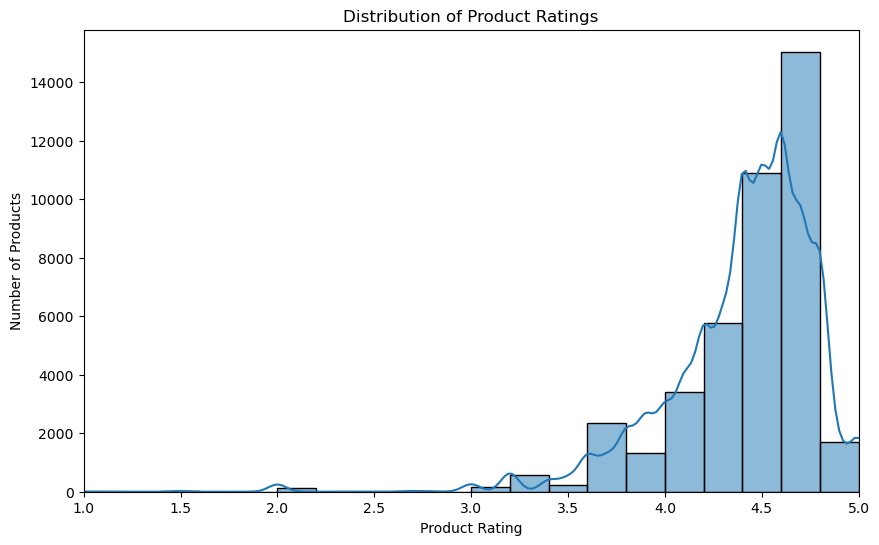

In [37]:
plt.figure(figsize=(10, 6))

sns.histplot(data=data,x="product_rating", bins=20,kde=True)

plt.title("Distribution of Product Ratings")
plt.xlabel("Product Rating")
plt.ylabel("Number of Products")
plt.xlim(1, 5)
plt.show()

### Observation

Most listings have ratings in the 4.0–5.0 range, with relatively few low-rated products.

# Product Category Distribution

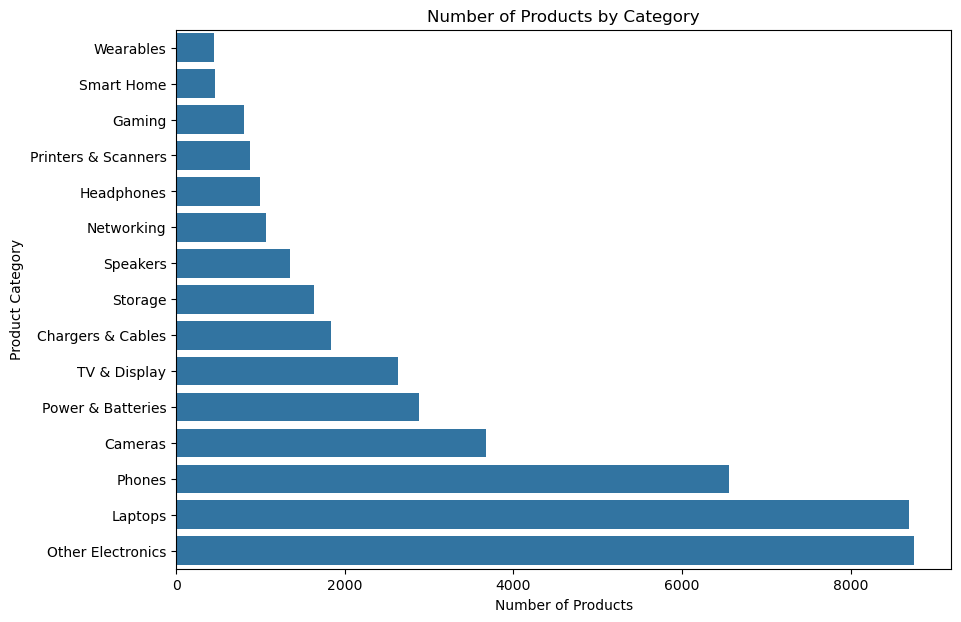

In [38]:
plt.figure(figsize=(10, 7))

category_counts = data["product_category"].value_counts().sort_values()
sns.barplot(x=category_counts.values, y=category_counts.index)

plt.title("Number of Products by Category")
plt.xlabel("Number of Products")
plt.ylabel("Product Category")

plt.show()

### Observation

The dataset is unevenly distributed across categories. Other Electronics, Laptops, and Phones contain the largest numbers of listings, so category comparisons should be considered alongside category size.

### Pricing and Discount Analysis

###  Discount Percentage Distribution

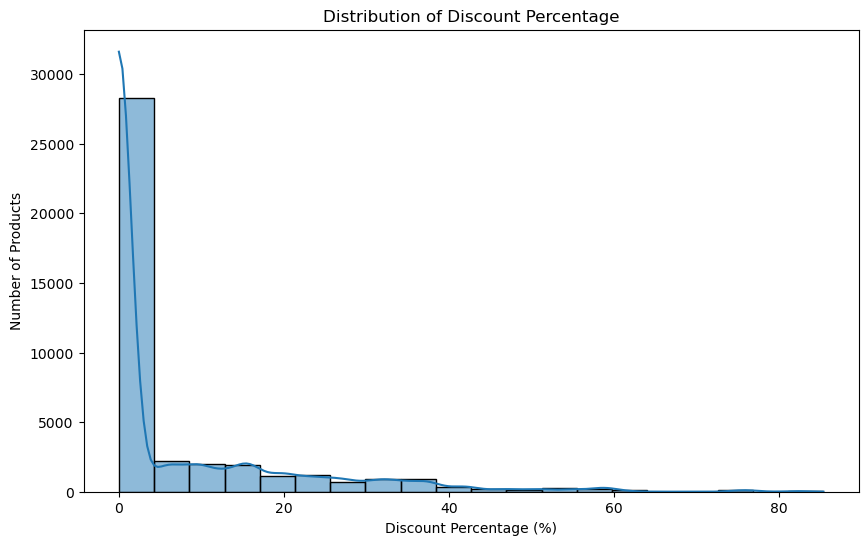

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(data=data,x="discount_percentage",bins=20,kde=True)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Number of Products")

plt.show()

### Observation

Most listings have relatively small discounts, with the distribution concentrated toward the lower end.

## Discounted Price Distribution

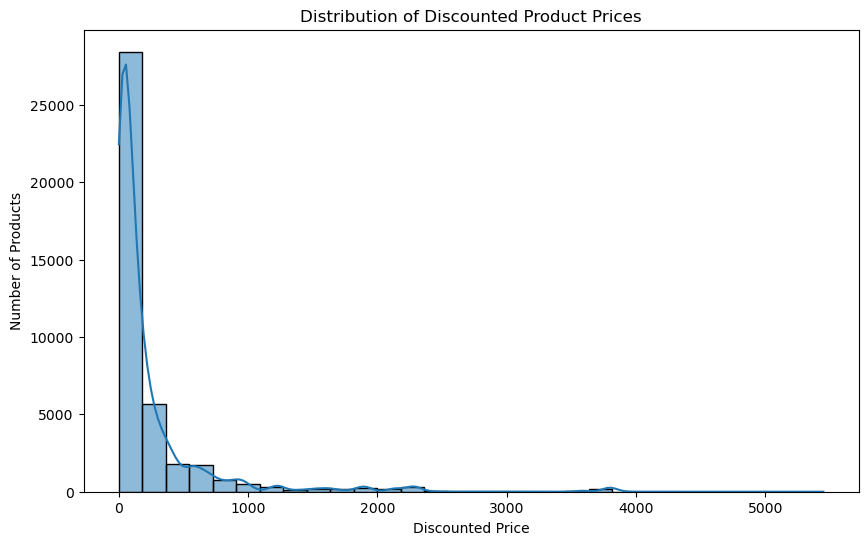

In [40]:
plt.figure(figsize=(10, 6))

sns.histplot(data=data,x="discounted_price",bins=30,kde=True)

plt.title("Distribution of Discounted Product Prices")
plt.xlabel("Discounted Price")
plt.ylabel("Number of Products")

plt.show()

### Observation

Discounted prices are heavily concentrated at the lower end, with a smaller number of expensive listings creating a long right tail.

###  Customer Engagement

## Total Reviews (Log-Transformed)

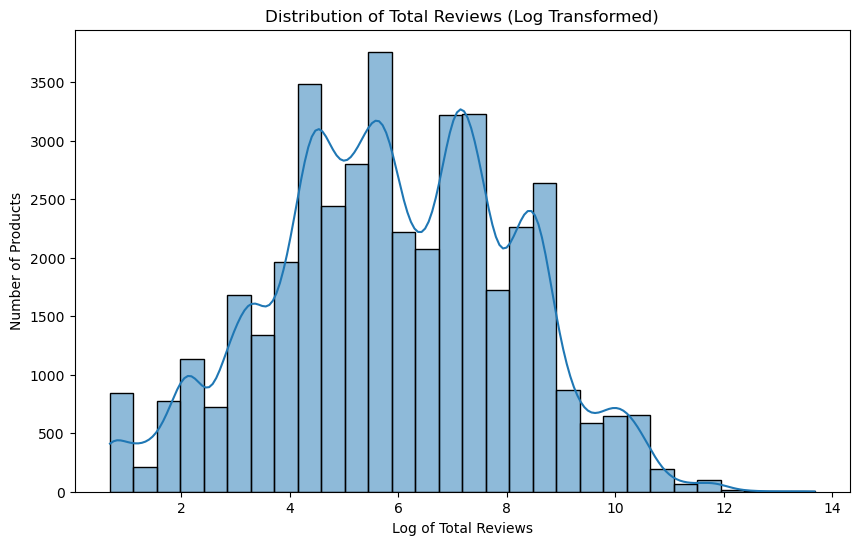

In [41]:
data["log_total_reviews"] = np.log1p(data["total_reviews"])

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="log_total_reviews",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Reviews (Log Transformed)")
plt.xlabel("Log of Total Reviews")
plt.ylabel("Number of Products")

plt.show()

## Purchases in the Last Month

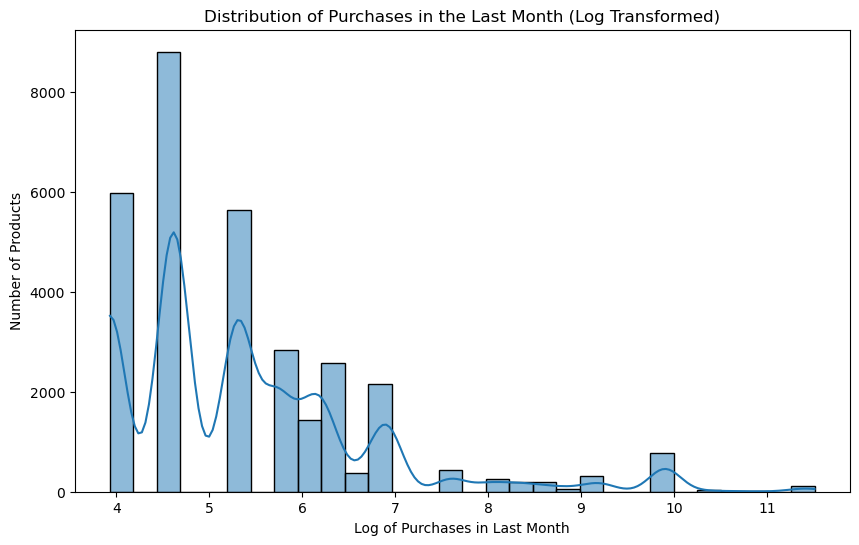

In [42]:
data["log_purchased_last_month"] = np.log1p(
    data["purchased_last_month"]
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="log_purchased_last_month",
    bins=30,
    kde=True
)

plt.title("Distribution of Purchases in the Last Month (Log Transformed)")
plt.xlabel("Log of Purchases in Last Month")
plt.ylabel("Number of Products")

plt.show()

### Observation

Purchase counts are highly right-skewed, with most listings at relatively low volumes and a small number of listings at very high volumes.

## Rating vs Purchases

Does product rating relate to purchases in the last month?

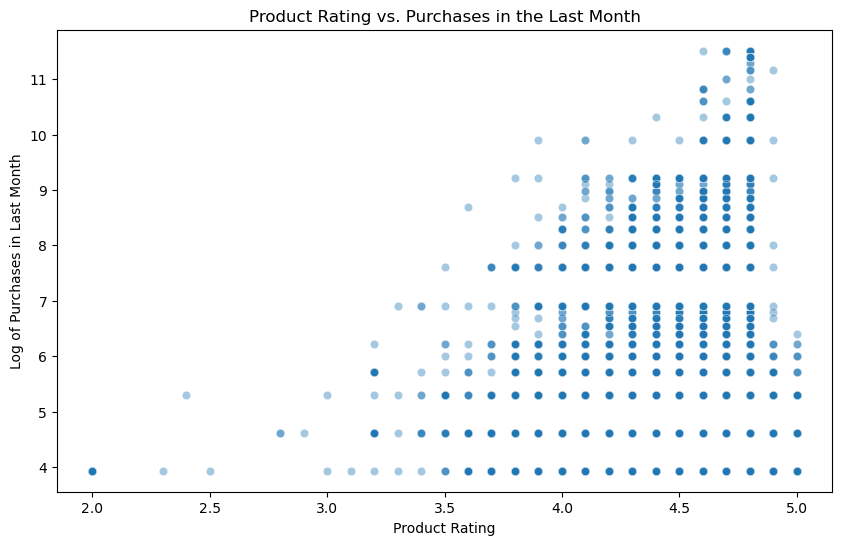

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="product_rating",
    y="log_purchased_last_month",
    alpha=0.4
)

plt.title("Product Rating vs. Purchases in the Last Month")
plt.xlabel("Product Rating")
plt.ylabel("Log of Purchases in Last Month")

plt.show()

### Observation

Higher-rated listings tend to have somewhat higher purchase activity, but the spread is wide. Rating alone does not explain demand.

## Discount vs Purchases

Is discount percentage associated with purchase activity?

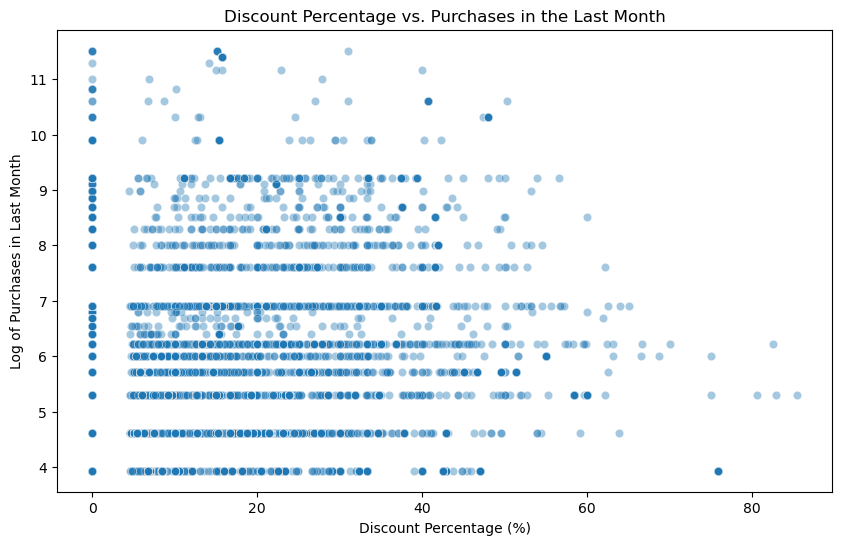

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="discount_percentage",
    y="log_purchased_last_month",
    alpha=0.4
)

plt.title("Discount Percentage vs. Purchases in the Last Month")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Log of Purchases in Last Month")

plt.show()

### Observation

Discount percentage does not show a strong linear relationship with purchase activity. High and low purchase levels appear across a wide range of discounts.

## Price vs Purchases

Is discounted price associated with purchase activity?

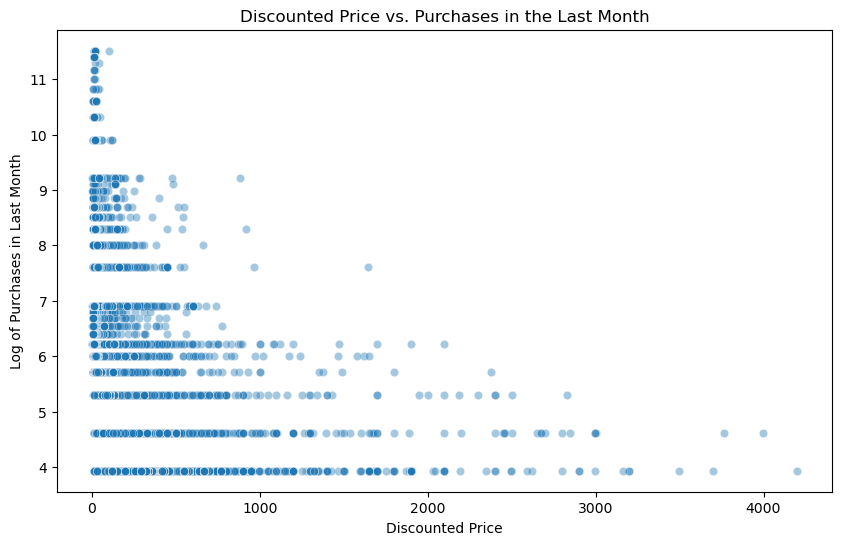

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="discounted_price",
    y="log_purchased_last_month",
    alpha=0.4
)

plt.title("Discounted Price vs. Purchases in the Last Month")
plt.xlabel("Discounted Price")
plt.ylabel("Log of Purchases in Last Month")

plt.show()

### Observation

Most listings are at lower price points. Higher purchase volumes are more common among lower-priced listings, although there are clear exceptions.

## Rating vs. Discount

Do highly rated products receive higher discounts?

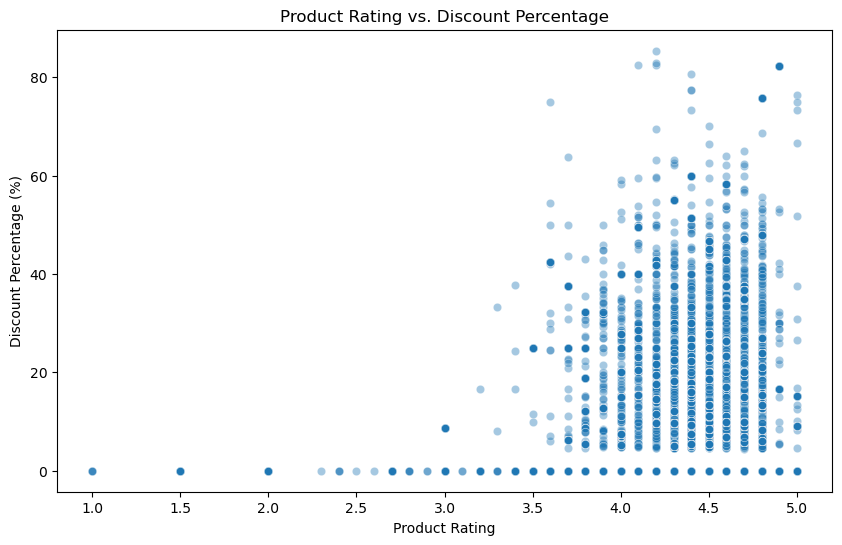

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="product_rating",
    y="discount_percentage",
    alpha=0.4
)

plt.title("Product Rating vs. Discount Percentage")
plt.xlabel("Product Rating")
plt.ylabel("Discount Percentage (%)")

plt.show()

### Observation

Ratings are concentrated in the higher range, and there is no obvious relationship between rating and discount percentage.

## Reviews vs Purchases
Do products with more reviews tend to have more purchases?

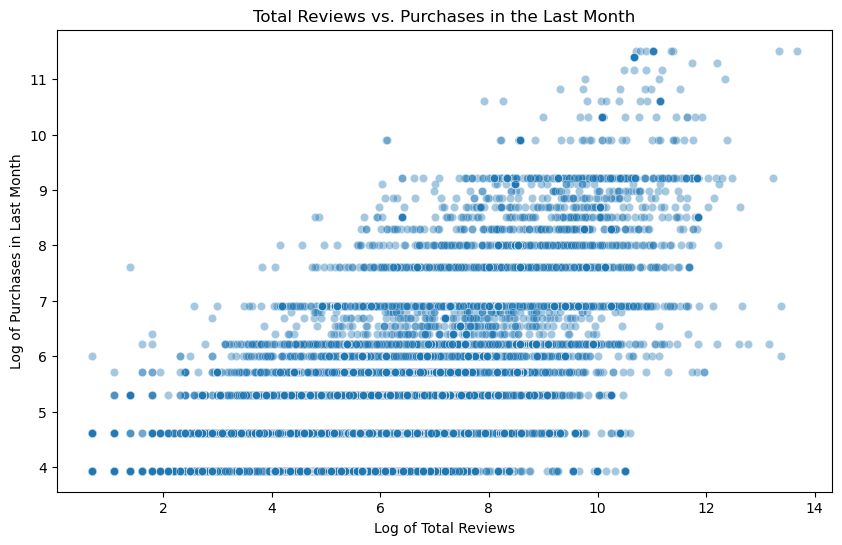

In [47]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="log_total_reviews",
    y="log_purchased_last_month",
    alpha=0.4
)

plt.title("Total Reviews vs. Purchases in the Last Month")
plt.xlabel("Log of Total Reviews")
plt.ylabel("Log of Purchases in Last Month")

plt.show()

### Observation

Listings with more reviews generally also show higher purchase activity. The relationship is positive, but there is still substantial variation between products.

## Product Category vs Purchases

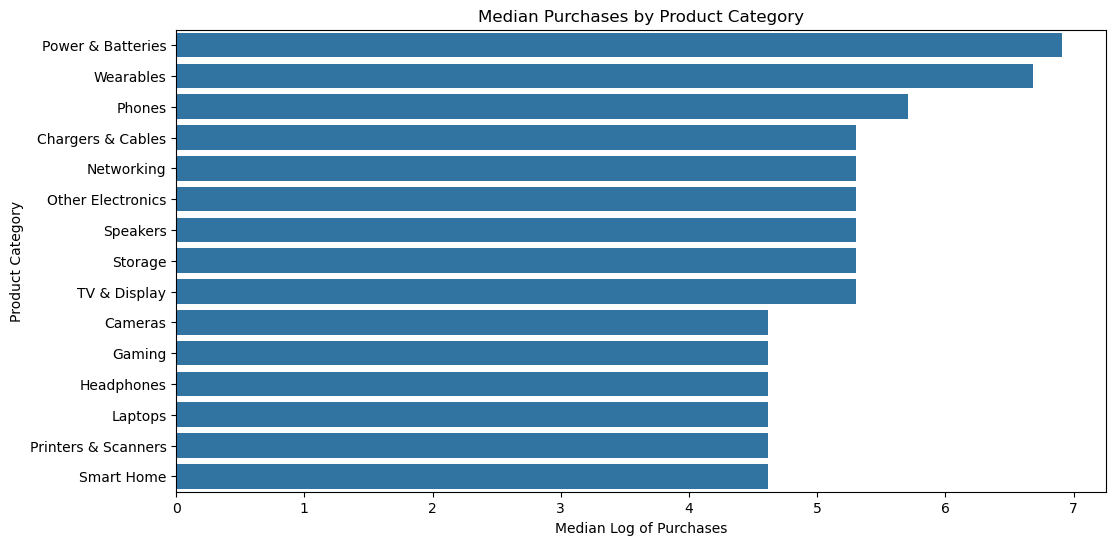

In [48]:
plt.figure(figsize=(12, 6))

category_sales = (
    data.groupby("product_category")["log_purchased_last_month"]
    .median()
    .sort_values(ascending=False)
)

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Median Purchases by Product Category")
plt.xlabel("Median Log of Purchases")
plt.ylabel("Product Category")

plt.show()

### Observation

Power & Batteries and Wearables have the highest typical purchase activity, while several categories such as Laptops and Headphones are lower.

## Correlation Heatmap

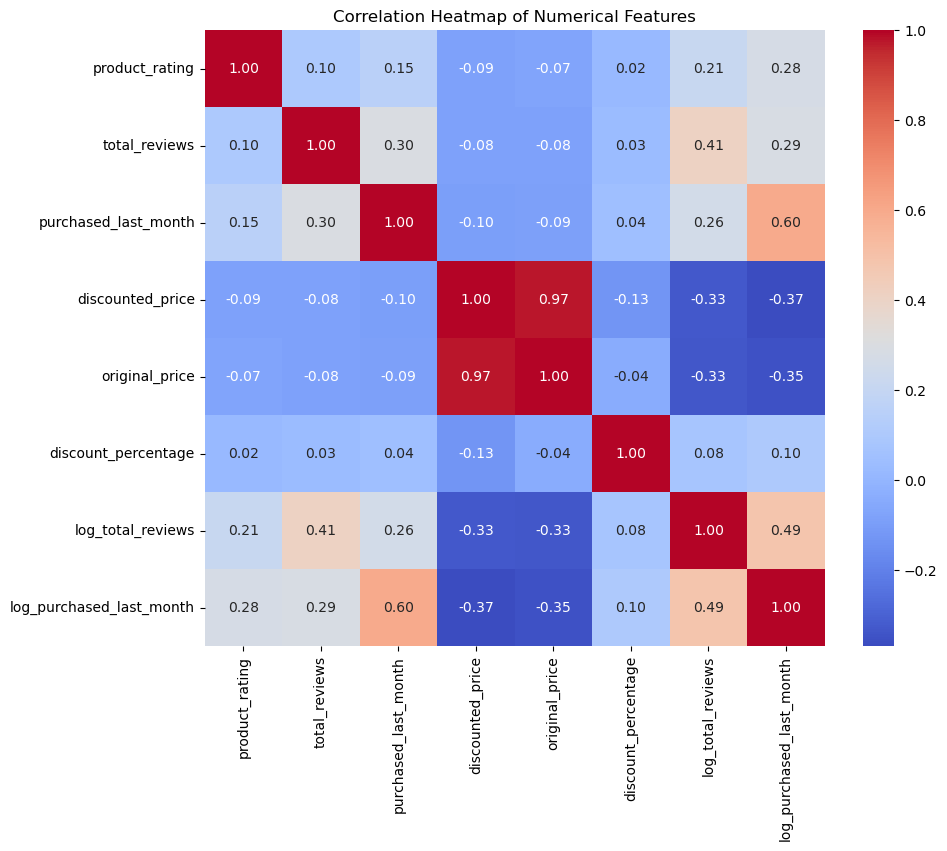

In [49]:
plt.figure(figsize=(10, 8))

numeric_data = data.select_dtypes(include="number")

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observation

Original and discounted prices are very strongly related. Among the purchase-related variables, review volume has a positive relationship with purchases, while price has a negative relationship.

###  Best Seller Performance

## Product Rating by Best Seller Status

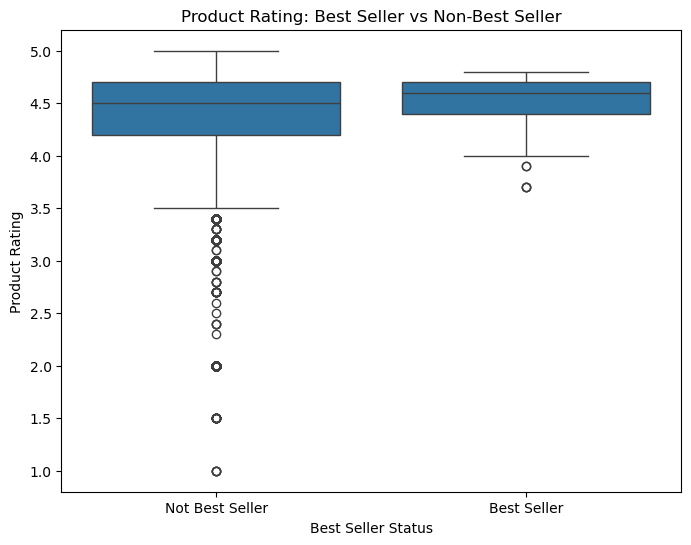

In [50]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="best_seller",
    y="product_rating"
)

plt.title("Product Rating: Best Seller vs Non-Best Seller")
plt.xlabel("Best Seller Status")
plt.ylabel("Product Rating")

plt.show()

### Observation

Best Seller products generally have slightly higher and more consistent ratings compared to Non-Best-Seller products, which show greater variation and several low-rating outliers.


## Price Distribution by Best Seller Status

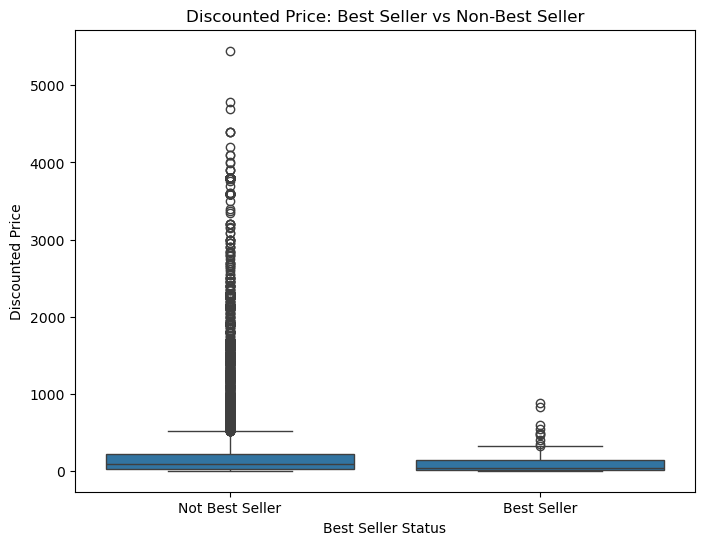

In [51]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="best_seller",
    y="discounted_price"
)

plt.title("Discounted Price: Best Seller vs Non-Best Seller")
plt.xlabel("Best Seller Status")
plt.ylabel("Discounted Price")

plt.show()

### Observation

Best Seller listings tend to have lower discounted prices, while Non-Best-Seller listings have a wider price range.

## Total Reviews by Best Seller Status

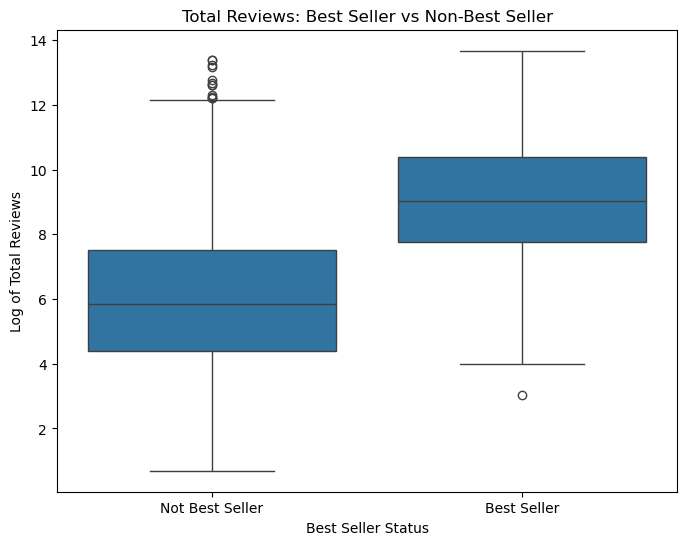

In [52]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="best_seller",
    y="log_total_reviews"
)

plt.title("Total Reviews: Best Seller vs Non-Best Seller")
plt.xlabel("Best Seller Status")
plt.ylabel("Log of Total Reviews")

plt.show()

### Observation

Best Seller listings have a higher typical review count than Non-Best-Seller listings.

## Discount Percentage by Best Seller Status

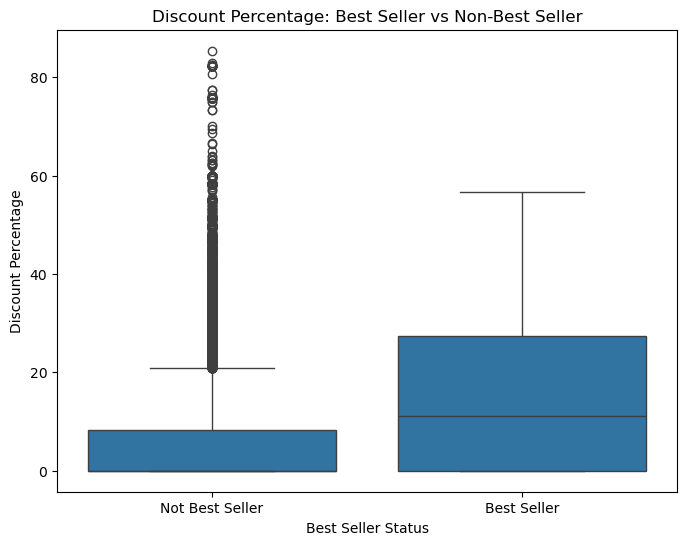

In [53]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="best_seller",
    y="discount_percentage"
)

plt.title("Discount Percentage: Best Seller vs Non-Best Seller")
plt.xlabel("Best Seller Status")
plt.ylabel("Discount Percentage")

plt.show()

### Observation

Best Seller listings show a somewhat higher typical discount, although both groups contain a wide range of discount values.

## Best Seller Rate by Product Category

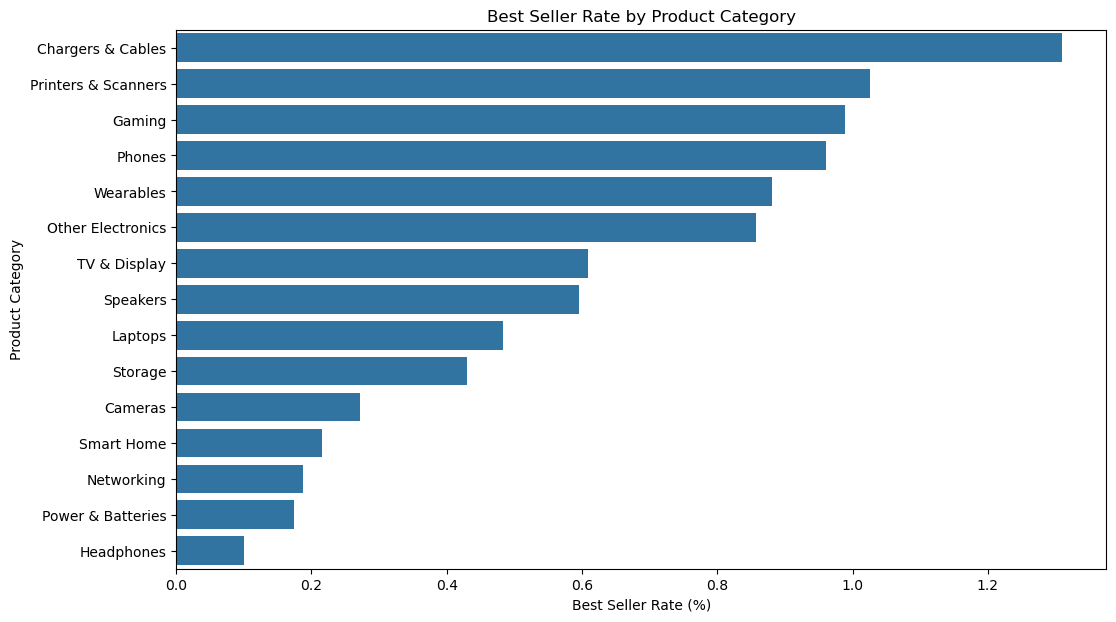

In [54]:
plt.figure(figsize=(12, 7))

best_seller_rate = (
    data.groupby("product_category")["best_seller"]
    .apply(lambda x: (x == "Best Seller").mean() * 100)
    .sort_values(ascending=False)
)

sns.barplot(
    x=best_seller_rate.values,
    y=best_seller_rate.index
)

plt.title("Best Seller Rate by Product Category")
plt.xlabel("Best Seller Rate (%)")
plt.ylabel("Product Category")

plt.show()

### Observation

Best Seller rates differ by category. Chargers & Cables have the highest rate in this dataset, while Headphones have one of the lowest.

## Discounted Price by Product Category

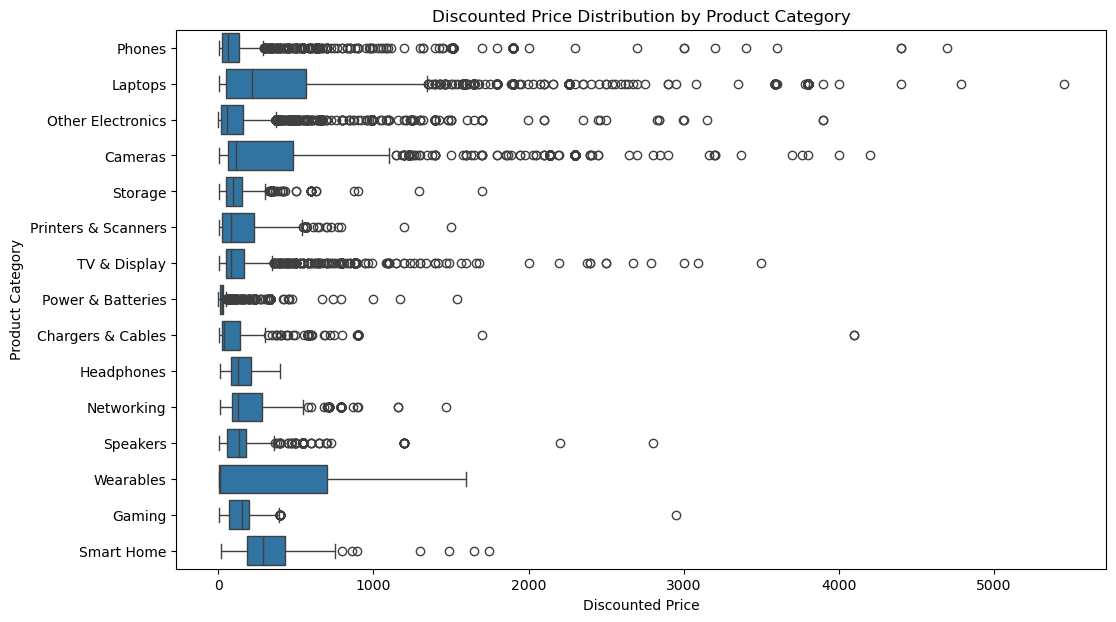

In [55]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=data,
    x="discounted_price",
    y="product_category"
)

plt.title("Discounted Price Distribution by Product Category")
plt.xlabel("Discounted Price")
plt.ylabel("Product Category")

plt.show()

### Observation

Price ranges differ substantially by category. Laptops, Wearables, and Smart Home have wider price ranges, while many other categories are concentrated at lower prices.

## Discount Percentage by Product Category

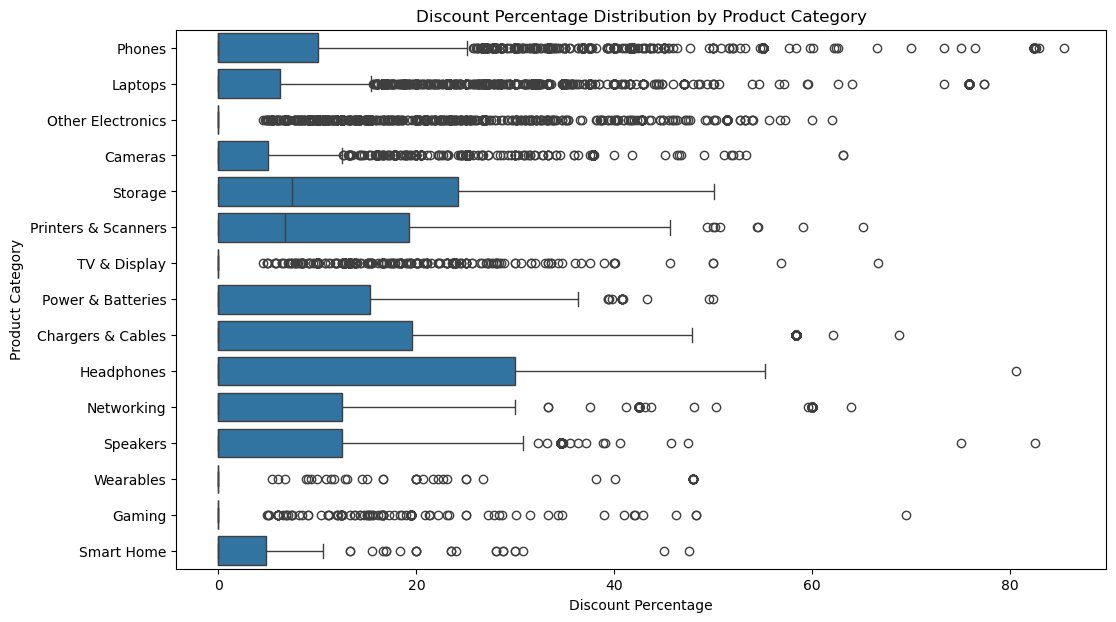

In [56]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=data,
    x="discount_percentage",
    y="product_category"
)

plt.title("Discount Percentage Distribution by Product Category")
plt.xlabel("Discount Percentage")
plt.ylabel("Product Category")

plt.show()

### Observation

Discount levels vary across categories. Some categories have higher typical discounts, while others show mostly low discounts with a few large outliers.

###  Purchase Behavior

## Product Rating vs Total Reviews

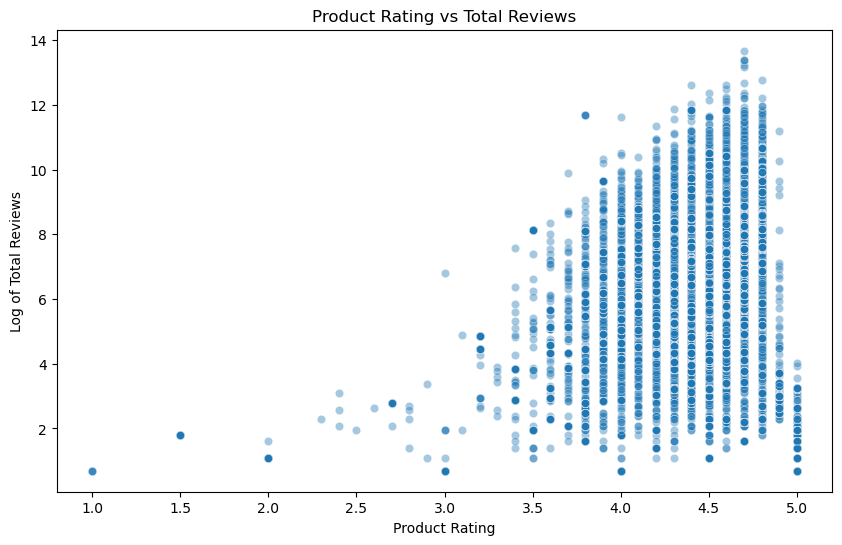

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="product_rating",
    y="log_total_reviews",
    alpha=0.4
)

plt.title("Product Rating vs Total Reviews")
plt.xlabel("Product Rating")
plt.ylabel("Log of Total Reviews")

plt.show()

### Observation

Most listings have ratings between about 4.0 and 5.0. Review counts vary widely even among products with similar ratings.

## Correlation Analysis: Purchases and Key Product Features

To make the purchase relationships easier to compare, I calculated correlations against `log_purchased_last_month`.

The log transformation reduces the influence of very large purchase counts; these values should be read as measures of association, not causal effects.

In [58]:
# Correlation of numerical features with purchases

purchase_corr = data[
    [
        "product_rating",
        "log_total_reviews",
        "discounted_price",
        "original_price",
        "discount_percentage",
        "log_purchased_last_month"
    ]
].corr()["log_purchased_last_month"].sort_values(ascending=False)

purchase_corr

log_purchased_last_month    1.000000
log_total_reviews           0.485663
product_rating              0.276529
discount_percentage         0.102622
original_price             -0.349202
discounted_price           -0.369654
Name: log_purchased_last_month, dtype: float64

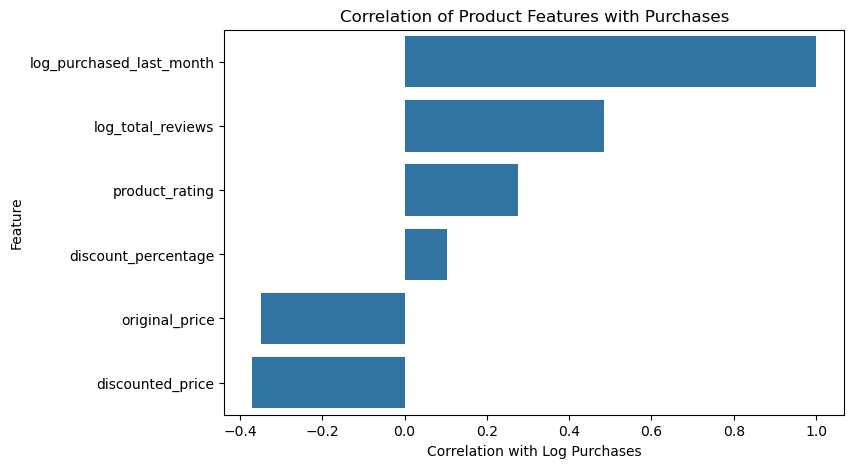

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=purchase_corr.values,
    y=purchase_corr.index
)

plt.title("Correlation of Product Features with Purchases")
plt.xlabel("Correlation with Log Purchases")
plt.ylabel("Feature")

plt.show()

### Observation

`log_total_reviews` has the strongest positive relationship with log purchases among the selected variables (about **0.49**).

Product rating is weaker (about **0.27**), while discount percentage is very weak (about **0.10**). Both original price and discounted price have negative correlations with log purchases (about **-0.35** and **-0.37**).

Overall, review volume and price show stronger associations with purchase activity than discount percentage does.

## Purchase Activity by Best Seller Status

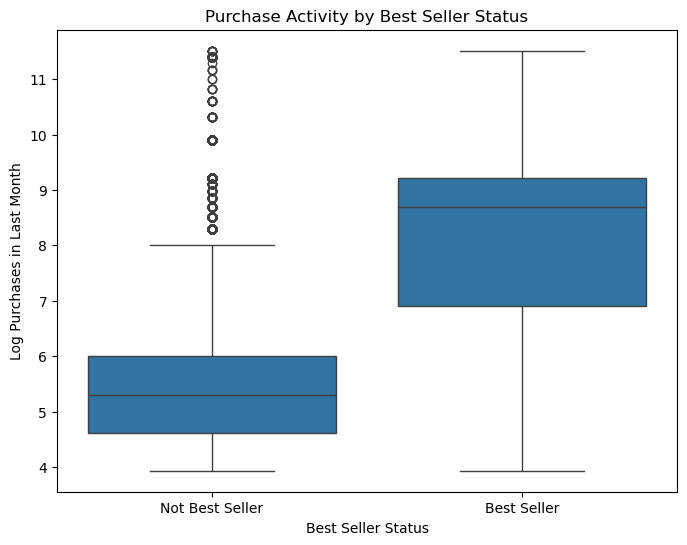

In [60]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="best_seller",
    y="log_purchased_last_month"
)

plt.title("Purchase Activity by Best Seller Status")
plt.xlabel("Best Seller Status")
plt.ylabel("Log Purchases in Last Month")

plt.show()

In [61]:
best_seller_purchases = (
    data.groupby("best_seller")["log_purchased_last_month"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

best_seller_purchases

,count,mean,median,std
best_seller,,,,
Best Seller,269,8.02,8.7,1.72
Not Best Seller,31895,5.37,5.3,1.34


### Observation

Best Seller listings have substantially higher purchase activity than Non-Best-Seller listings. On the log scale, the median is about **8.70** for Best Sellers versus **5.30** for Non-Best-Sellers.

Only **269 Best Seller listings** have non-missing purchase data, compared with **31,895 Non-Best-Seller listings**. The large difference in group size is important when interpreting the comparison.

The boxplot also shows considerable variation within both groups, so Best Seller status should be treated as a strong association rather than a guarantee of high sales.

## Statistical Significance Test: Best Seller vs Non-Best-Seller

In [62]:
print("Missing values in log_purchased_last_month:",
      data["log_purchased_last_month"].isna().sum())

print("\nMissing values by Best Seller status:")
print(
    data.groupby("best_seller")["log_purchased_last_month"]
    .apply(lambda x: x.isna().sum())
)

Missing values in log_purchased_last_month: 10511

Missing values by Best Seller status:
best_seller
Best Seller            6
Not Best Seller    10505
Name: log_purchased_last_month, dtype: int64


In [63]:
best_seller = data.loc[
    data["best_seller"] == "Best Seller",
    "log_purchased_last_month"
].dropna()

not_best_seller = data.loc[
    data["best_seller"] == "Not Best Seller",
    "log_purchased_last_month"
].dropna()

statistic, p_value = mannwhitneyu(
    best_seller,
    not_best_seller,
    alternative="two-sided"
)

rank_biserial = (2 * statistic / (len(best_seller) * len(not_best_seller))) - 1

print("Best Seller observations:", len(best_seller))
print("Not Best Seller observations:", len(not_best_seller))
print("Mann-Whitney U Statistic:", statistic)
print("P-value:", p_value)
print("Rank-biserial effect size:", round(rank_biserial, 3))

Best Seller observations: 269
Not Best Seller observations: 31895
Mann-Whitney U Statistic: 7481152.5
P-value: 1.1229638970629823e-101
Rank-biserial effect size: 0.744


The Mann–Whitney U test compares the purchase-activity distributions of Best Seller and Non-Best-Seller listings without assuming a normal distribution. I also included a rank-biserial effect size so the result is not based on the p-value alone.

In [64]:
alpha = 0.05

if p_value < alpha:
    print("Result: The difference is statistically significant.")
else:
    print("Result: The difference is not statistically significant.")

Result: The difference is statistically significant.


### Observation

The Mann–Whitney U test gives a p-value far below 0.05, so the difference in purchase activity between the two groups is statistically significant.

The rank-biserial effect size is about **0.74**, which indicates a large difference in the two distributions. This supports the descriptive finding that Best Seller listings tend to have much higher purchase activity.

This is still an observational comparison; it does not show that receiving a Best Seller badge causes higher purchases.

## High-Demand Products by Category

To identify the strongest-performing listings, I defined **High Demand** as products at or above the 90th percentile of `purchased_last_month`.

This gives a relative definition of high demand based on this dataset rather than using an arbitrary sales threshold.

In [65]:
high_demand_threshold = data["purchased_last_month"].quantile(0.90)

high_demand_products = data[
    data["purchased_last_month"] >= high_demand_threshold
]

high_demand_by_category = (
    high_demand_products["product_category"]
    .value_counts()
    .reset_index()
)

high_demand_by_category.columns = [
    "Product Category",
    "High-Demand Products"
]

high_demand_by_category

,Product Category,High-Demand Products
0,Power & Batteries,1605
1,Phones,1122
2,Laptops,532
3,Other Electronics,410
4,Chargers & Cables,150
5,Cameras,141
6,Storage,129
7,TV & Display,125
8,Networking,49
9,Headphones,46


### Observation

Raw high-demand counts are influenced by category size. I therefore also calculated the high-demand rate within each category.

### High-Demand Rate by Product Category

In [66]:
high_demand_rate = (
    data.groupby("product_category")["purchased_last_month"]
    .apply(
        lambda x: (x >= high_demand_threshold).mean() * 100
    )
    .sort_values(ascending=False)
    .reset_index(name="High-Demand Rate (%)")
)

high_demand_rate

,product_category,High-Demand Rate (%)
0,Power & Batteries,55.787278
1,Phones,17.095840
2,Chargers & Cables,8.183306
3,Storage,7.914110
4,Wearables,6.828194
5,Laptops,6.119867
6,Smart Home,5.376344
7,TV & Display,4.752852
8,Other Electronics,4.683038
9,Headphones,4.613842


### Observation

Power & Batteries has the highest high-demand rate at **55.79%**, followed by Phones at **17.10%**. Most other categories are below 10%.

This rate is more useful than raw high-demand counts for comparing categories of different sizes.

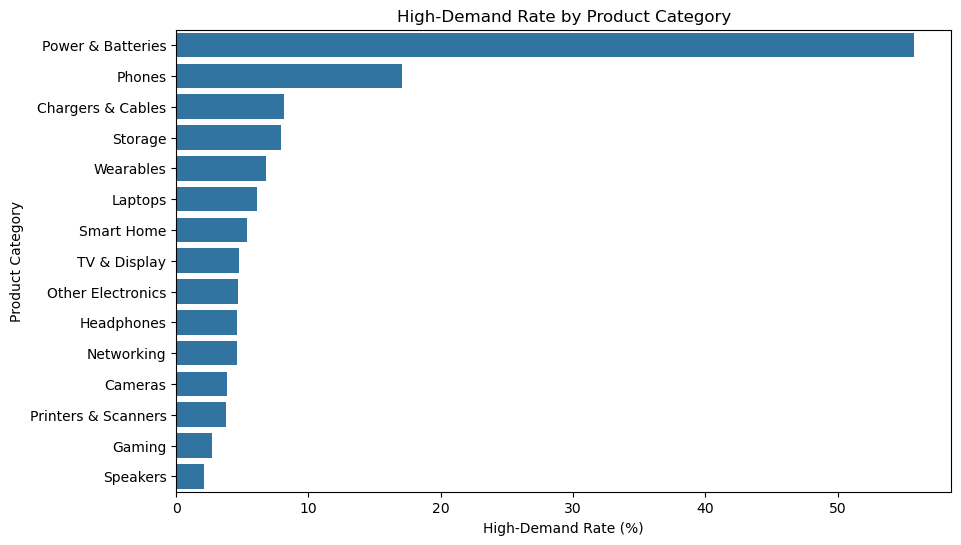

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=high_demand_rate,
    x="High-Demand Rate (%)",
    y="product_category"
)

plt.title("High-Demand Rate by Product Category")
plt.xlabel("High-Demand Rate (%)")
plt.ylabel("Product Category")

plt.show()

### Observation

Power & Batteries stands out because more than half of its listings fall into the high-demand group. Phones are a distant second, while most other categories have much smaller shares.

## Create the High-Demand flag

In [68]:
data["high_demand"] = np.where(
    data["purchased_last_month"] >= high_demand_threshold,
    "High Demand",
    "Other"
)

high_demand_summary = (
    data.groupby("high_demand")[
        [
            "product_rating",
            "total_reviews",
            "discount_percentage",
            "discounted_price"
        ]
    ]
    .median()
    .round(2)
)

high_demand_summary

,product_rating,total_reviews,discount_percentage,discounted_price
high_demand,,,,
High Demand,4.7,5045.0,0.0,25.47
Other,4.5,288.0,0.0,93.99


### Observation

Compared with other listings, High-Demand products have:

- Median rating: **4.7 vs 4.5**
- Median reviews: **5,045 vs 288**
- Median discount: **0% vs 0%**
- Median discounted price: **25.47 vs 93.99**

The strongest differences are review volume and price. Discount percentage does not separate the two groups in this dataset.

## High-Demand Products by Best Seller Status

In [69]:
high_demand_best_seller = pd.crosstab(
    data["high_demand"],
    data["best_seller"],
    normalize="index"
) * 100

high_demand_best_seller.round(2)

best_seller,Best Seller,Not Best Seller
high_demand,,
High Demand,4.70,95.30
Other,0.17,99.83


### Observation

Best Seller listings are disproportionately represented among High-Demand products: **4.70%** of High-Demand listings are Best Sellers compared with **0.17%** of Other listings.

## Coupon Availability and Purchase Demand

I compared the median purchase activity of listings with and without a coupon. Median values are used because purchase counts are heavily skewed.

### Observation

Listings with a coupon have median purchase activity of **700**, compared with **200** for listings without a coupon.

This is an association in the observed data. It does not show that adding a coupon would increase purchases by the same amount.

## Sponsored vs Organic Product Performance

Sponsored and organic listings were compared using the same purchase metrics. This comparison describes the observed listing mix; it should not be interpreted as an advertising causal test.

In [70]:
sponsored_summary = (
    data.groupby("is_sponsored")["purchased_last_month"]
    .agg(["count", "median", "mean"])
    .round(0)
    .reset_index()
)

sponsored_summary

,is_sponsored,count,median,mean
0,Organic,28561,200.0,488.0
1,Sponsored,3603,1000.0,7681.0


### Observation

Sponsored listings have higher purchase activity in this dataset:

- Organic: median **200**, mean **488**
- Sponsored: median **1,000**, mean **7,681**

The large gap between the sponsored mean and median suggests that a small number of sponsored listings have exceptionally high purchase activity.

## High-Demand Rate by Sponsored Status

I also compared the share of High-Demand listings across sponsored and organic groups.

In [71]:
high_demand_sponsored = (
    pd.crosstab(
        data["is_sponsored"],
        data["high_demand"],
        normalize="index"
    ) * 100
)

high_demand_sponsored.round(2)

high_demand,High Demand,Other
is_sponsored,,
Organic,5.79,94.21
Sponsored,33.99,66.01


### Observation

About **33.99%** of Sponsored listings are High Demand, compared with **5.79%** of Organic listings.

This is a strong association, but sponsored placement may be targeted toward products that already have stronger demand or other favorable characteristics.

## Purchase Activity by Price Segment

I divided discounted prices into four equal-sized groups using quartiles. This makes the comparison less sensitive to the very wide price range in the dataset.

In [72]:
data["price_segment"] = pd.qcut(
    data["discounted_price"],
    q=4,
    labels=["Low Price", "Mid-Low Price", "Mid-High Price", "High Price"]
)

price_segment_summary = (
    data.groupby("price_segment", observed=True)["purchased_last_month"]
    .agg(["count", "median", "mean"])
    .round(2)
    .reset_index()
)

price_segment_summary

,price_segment,count,median,mean
0,Low Price,8832,500.0,3794.40
1,Mid-Low Price,7497,200.0,495.30
2,Mid-High Price,8258,100.0,354.36
3,High Price,5717,50.0,139.73


### Observation

Median purchases fall as the price segment increases:

- Low Price: **500**
- Mid-Low Price: **200**
- Mid-High Price: **100**
- High Price: **50**

The low-price group also has a much higher mean than median, showing that a small number of low-priced listings have very high purchase activity.

## Product Performance Summary

This table brings together category size, typical purchase activity, ratings, reviews, discounts, and Best Seller rate so the category comparisons can be viewed in one place.

In [73]:
performance_summary = (
    data.groupby("product_category")
    .agg(
        Products=("product_title", "count"),
        Median_Purchases=("purchased_last_month", "median"),
        Average_Rating=("product_rating", "mean"),
        Median_Reviews=("total_reviews", "median"),
        Average_Discount=("discount_percentage", "mean"),
        Best_Seller_Rate=("best_seller", lambda x: (x == "Best Seller").mean() * 100)
    )
    .round(2)
    .sort_values("Median_Purchases", ascending=False)
    .reset_index()
)

performance_summary

,product_category,Products,Median_Purchases,Average_Rating,Median_Reviews,Average_Discount,Best_Seller_Rate
0,Power & Batteries,2877,1000.0,4.61,3304.0,5.92,0.17
1,Wearables,454,800.0,4.50,1320.0,3.07,0.88
2,Phones,6563,300.0,4.30,988.0,8.63,0.96
3,Chargers & Cables,1833,200.0,4.41,202.0,12.64,1.31
4,Networking,1070,200.0,4.23,328.0,11.24,0.19
5,Other Electronics,8755,200.0,4.43,376.0,3.11,0.86
6,Speakers,1345,200.0,4.50,209.0,7.09,0.59
7,Storage,1630,200.0,4.36,125.0,11.69,0.43
8,TV & Display,2630,200.0,4.49,264.0,3.34,0.61
9,Cameras,3677,100.0,4.50,293.0,4.72,0.27


### Observation

Power & Batteries has the highest median purchase activity (**1,000**), followed by Wearables (**800**) and Phones (**300**).

Large categories do not automatically have higher typical demand. For example, Laptops and Other Electronics have many listings but lower median purchase activity.

This is why category size and category performance should be considered separately.

# Key Findings

### 1. Demand is concentrated in a few categories

Power & Batteries has the highest median purchase activity at **1,000**, followed by Wearables at **800** and Phones at **300**. Power & Batteries also has the highest High-Demand rate at **55.79%**.

### 2. Best Seller listings have much higher purchase activity

Best Seller listings have a substantially higher purchase distribution than Non-Best-Seller listings. The Mann–Whitney U test confirms that the difference is statistically significant, with a large rank-biserial effect size of about **0.74**.

### 3. Price and review volume are stronger signals than discount percentage

Lower-priced listings generally have higher purchase activity, while review volume has the strongest positive correlation with log purchases (about **0.49**). Discount percentage has only a weak correlation (about **0.10**).

### 4. Coupons and sponsored listings are associated with higher demand

Coupon-enabled and Sponsored listings both show higher purchase activity than their comparison groups. These findings are useful for further testing, but the dataset does not establish that coupons or sponsored placement directly cause the higher purchases.

# Business Recommendations

Based on the observed patterns, I would focus on the following actions:

1. **Prioritize strong categories.** Power & Batteries and Wearables show high typical purchase activity, so they are worth closer attention for assortment and inventory planning.

2. **Use price together with category context.** Lower-priced listings generally show higher purchase activity, but pricing decisions should be made within each product category rather than across the whole dataset.

3. **Track review volume as a demand signal.** Review count has the strongest positive association with purchase activity among the selected numeric features. It can be monitored alongside sales rather than treated as a cause of sales.

4. **Test promotions instead of assuming they work.** Coupons and sponsored listings are associated with higher demand. A controlled experiment or before/after analysis would be needed to estimate their incremental impact.

5. **Use category-level metrics.** Category size, median purchases, and High-Demand rate should be reviewed together because a large number of listings does not necessarily mean stronger typical demand.

# Limitations

- **Purchase values are capped at a high upper limit.** Many records reach 100,000 purchases, so the exact ranking of the highest-selling listings may be affected by the cap.
- **Rows represent listings/records.** Product titles are repeated, so the analysis should not be interpreted as a unique-product analysis.
- **Missing purchase values are substantial.** Purchase-based comparisons use only records with available purchase data; missing values were not treated as zero.
- **Best Seller groups are highly imbalanced.** Only a small number of listings are Best Sellers, so group comparisons should be interpreted with the difference in sample size in mind.
- **This is observational, point-in-time data.** The results show associations and cannot establish that price, coupons, sponsorship, ratings, or reviews cause changes in purchases.